In [1]:
import numpy as np
import os
import glob 
import time 
import pandas as pd
import shutil
import re
import mdtraj as md
import MDAnalysis as mda
import pickle
import pickle as p 
import csv
import sys
import subprocess
import xml.etree.ElementTree as ET
import requests
import concurrent.futures
import multiprocessing
import nglview as nv
import h5py
import matplotlib as mpl
import matplotlib.patheffects as path_effects
import matplotlib.patches as patches
import html
import biobox as bb
import tempfile
import matplotlib.pyplot as plt
import molearn
import torch
import glob as glob
import MDAnalysis.analysis.rms as rms
import seaborn as sns
import pickle
import networkx as nx
sys.path.insert(0, os.path.join(os.path.abspath(os.pardir),'src'))

from Bio import PDB
from tqdm import tqdm
from time import time as t
from urllib.request import urlretrieve as download
from Bio.Blast import NCBIWWW, NCBIXML
from Bio.Blast.Applications import NcbipsiblastCommandline
from collections import defaultdict
from Bio.PDB import PPBuilder
from Bio.SeqUtils import seq1
from modeller import *
from modeller.automodel import *
from Bio.PDB import PDBParser
from MDAnalysis.analysis import align
from mpi4py import MPI
from glob import glob
from pprint import pprint as pp
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from glob import glob as g
from tqdm.notebook import tqdm
from collections import Counter
from matplotlib.ticker import FuncFormatter
from collections import defaultdict
from pymol import cmd
from scipy.interpolate import interp1d
from mpl_toolkits import mplot3d
from scipy import stats
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from matplotlib.colors import BoundaryNorm
from numpy.linalg import norm
from molearn.data import PDBData
from molearn.trainers import Trainer
from molearn.models.small_foldingnet import Small_AutoEncoder
from molearn.analysis.analyser import MolearnAnalysis
from copy import deepcopy
from molearn.analysis import MolearnGUI
from scipy.ndimage import rotate
from numpy.linalg import inv
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score
from itertools import combinations
from urllib.request import urlretrieve
from urllib.error import URLError
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.tree import export_graphviz
from sklearn import tree
from scipy.stats import pearsonr


/data/student/xujia/miniforge3/envs/project/lib/python3.10/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
mkdir -p failed for path /home/student/.config/matplotlib: [Errno 13] Permission denied: '/home/student'
Matplotlib created a temporary cache directory at /tmp/matplotlib-evtfi4vd because there was an issue with the default path (/home/student/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/data/student/xujia/miniforge3/envs/project/lib/python3.10/site-packages/molearn/trainers/sinkhorn_trainer.py:13: UserWarning: No module named 'geomloss'. Will not be able to use sinkhorn 

Learning the conformational ensemble with an Autoencoder.

In [3]:
"""
This script trains a Small_AutoEncoder on a folder of aligned protein structures by first merging individual PDB files into a multi-model combined.pdb, selecting backbone atoms, and then splitting the dataset into fixed training and test sets using a manual random seed. It initializes a Trainer with the training data and iteratively trains the autoencoder, saving the best checkpoint and logging progress.
"""

#fixed splitting strategy
from copy import deepcopy
def train_autoencoder_on_folder(folder_name, checkpoint_suffix):
    print(f"\n Starting training on: {folder_name}")
    data = PDBData()

    # Get files, excluding combined.pdb
    files = sorted([
        f for f in os.listdir(folder_name) 
        if os.path.isfile(os.path.join(folder_name, f)) and f != 'combined.pdb'
    ])

    # Merge into combined.pdb
    combined_file_path = os.path.join(folder_name, 'combined.pdb')
    with open(combined_file_path, 'w') as combined_file:
        for i, filename in enumerate(files):
            file_path = os.path.join(folder_name, filename)
            with open(file_path, 'r') as file:
                lines = file.readlines()
                lines = [line for line in lines if not line.startswith(("MODEL", "END"))]

            combined_file.write(f'MODEL {i}\n')
            combined_file.writelines(lines)
            combined_file.write('ENDMDL\n')
        combined_file.write('END\n')

    # Load and prepare data
    data.import_pdb(filename=combined_file_path)
    data.fix_terminal()
    data.atomselect(atoms=['CA', 'C', 'N', 'CB', 'O'])
    data.prepare_dataset()
    print(data._mol)

    # Split data
    # Get indices
    # Assume combined.pdb contains N models
    num_models = data.dataset.shape[0]
    manual_seed = 25
    valid_ratio = 0.1  # Proportion of validation set

    # Set random seed and shuffle model indices
    indices = np.random.RandomState(seed=manual_seed).permutation(num_models)

    # Split according to ratio
    num_test = int(num_models * valid_ratio)
    test_indices = indices[:num_test]
    train_indices = indices[num_test:]

    # Save to text files
    np.savetxt(f"train_model_indices_{checkpoint_suffix}.txt", train_indices, fmt='%d')
    np.savetxt(f"test_model_indices_{checkpoint_suffix}.txt", test_indices, fmt='%d')

    # Create subset PDBData objects
    from copy import deepcopy
    data_train_obj = deepcopy(data)
    data_test_obj = deepcopy(data)
    data_train_obj.dataset = data.dataset[train_indices]
    data_test_obj.dataset = data.dataset[test_indices]
    print(f"NUM OF TRAIN SET: {len(data_train_obj.dataset)}")
    print("FINISH")

    # Set up trainer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trainer = Trainer(device=device)
    trainer.set_data(data_train_obj, batch_size=8, validation_split=0.1, manual_seed=25)
    trainer.set_autoencoder(Small_AutoEncoder, out_points=data.dataset.shape[-1])
    trainer.prepare_optimiser()

    # Set output folder path
    base_result_dir = f'Results/run_trial_BRAFActivationLoop_postalign_{checkpoint_suffix}'
    log_file = os.path.join(base_result_dir, 'xbb_foldingnet_checkpoints', 'log_file.dat')
    log_folder = os.path.join(base_result_dir, 'xbb_foldingnet_checkpoints')
    checkpoint_folder = base_result_dir

    os.makedirs(log_folder, exist_ok=True)

    # Start training
    best = 1e24
    while True:
        trainer.run(max_epochs=32 + trainer.epoch,
                    log_filename='log_file.dat',
                    log_folder=log_folder,
                    checkpoint_folder=checkpoint_folder)
        if not best > trainer.best:
            break
        best = trainer.best

    print(f" Training completed for {folder_name}")
    print(f"   Best loss: {trainer.best:.4f}")
    print(f"   Best checkpoint: {trainer.best_name}")

if __name__ == '__main__':
    # Path: RMSD ≤ 11
    folder = 'Results/fitted_matlab_segments/foldseek_endsAlignment_cleaned_noOutliers_noPCAoutliers'
    
    suffix = 'cleaned_noOutlier_11_checkpoint_newsplit'

    #Train
    train_autoencoder_on_folder(folder, suffix)



 Starting training on: Results/fitted_matlab_segments/foldseek_endsAlignment_cleaned_noOutliers_noPCAoutliers
Dataset.shape: torch.Size([1042, 3, 30])
mean: 110.49572083599914, std: 20.398020657930815
NUM OF TRAIN SET: 938
FINISH
device: cpu
{"train_mse_loss": 0.2248004284924304, "train_loss": 0.2248004284924304, "valid_mse_loss": 0.03317661813750703, "valid_loss": 0.03317661813750703, "epoch": 0, "train_seconds": 5.422813177108765, "valid_seconds": 0.15205883979797363, "checkpoint_seconds": 0.19521474838256836, "total_seconds": 5.770086765289307}
{"train_mse_loss": 0.03233985964363143, "train_loss": 0.03233985964363143, "valid_mse_loss": 0.03597373539401639, "valid_loss": 0.03597373539401639, "epoch": 1, "train_seconds": 5.2981579303741455, "valid_seconds": 0.1521601676940918, "checkpoint_seconds": 0.21227407455444336, "total_seconds": 5.662592172622681}
{"train_mse_loss": 0.026103791889883356, "train_loss": 0.026103791889883356, "valid_mse_loss": 0.021598485228355214, "valid_loss": 

In [4]:
import glob
file_pattern = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_*.ckpt'

print(glob.glob(file_pattern))

matching_files = sorted(glob.glob(file_pattern))

if len(matching_files) == 0:
    raise FileNotFoundError(f"No files matched the pattern: {file_pattern}")

networkfile = matching_files[0]

checkpoint = torch.load(networkfile, map_location=torch.device('cpu'),weights_only=False)
net = Small_AutoEncoder(**checkpoint['network_kwargs'])
net.load_state_dict(checkpoint['model_state_dict'])

print("Matched files:", matching_files)
print("Using file:", networkfile)
print("Network kwargs:", checkpoint['network_kwargs'])

['Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch270_loss0.0024063686529795327.ckpt']
Matched files: ['Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch270_loss0.0024063686529795327.ckpt']
Using file: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/checkpoint_epoch270_loss0.0024063686529795327.ckpt
Network kwargs: {'out_points': 30}


In [6]:
import os
data = PDBData()
folder_name = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
folder_name="Results/fitted_matlab_segments/foldseek_endsAlignment_cleaned_noOutliers_noPCAoutliers"
combined_file_path = os.path.join(folder_name, 'combined.pdb')
data.import_pdb(filename=combined_file_path)
data.fix_terminal()
data.atomselect(atoms = ['CA', 'C', 'N', 'CB', 'O'])
data.prepare_dataset()

Dataset.shape: torch.Size([1042, 3, 30])
mean: 110.49572083599914, std: 20.398020657930815


In [7]:
from copy import deepcopy
MA = MolearnAnalysis()
MA.set_network(net)

checkpoint_suffix = 'cleaned_noOutlier_11_checkpoint_newsplit'
train_file = f"train_model_indices_{checkpoint_suffix}.txt"
test_file = f"test_model_indices_{checkpoint_suffix}.txt"

train_indices = np.loadtxt(train_file, dtype=int)
test_indices = np.loadtxt(test_file, dtype=int)

print("Train indices loaded:", train_indices.shape)
print("Test indices loaded:", test_indices.shape)
print(test_indices)

data_train = deepcopy(data)
data_test = deepcopy(data)
data_train.dataset = data.dataset[train_indices]
data_test.dataset = data.dataset[test_indices]
data_train.indices = train_indices
data_test.indices = test_indices

MA.set_dataset("training", data_train)
MA.set_dataset("test", data_test)


Train indices loaded: (938,)
Test indices loaded: (104,)
[ 505  733  805  584  906  221  136  676  444  635  123  653  956  314
  437  620   49  787  762  884  219  190  589  162  344  404  196 1019
  347  745  856  659  113  854  730   94  516   61  271   69  360   95
  963  297  792  495  419  498  958  163  484  302  543   92  799  415
  537  595  270  687  794   35  652  874  907  195  724  573  194  924
    7  172  132  550  459   74  619   21  179  273  186  119  613  633
  812  999  215  923  942  153  542  234   39  899  488  423  634  763
  917  394  875  754  276  795]


In [8]:
"""
Save structures for training dataset
"""
def ifnotmake(dir_path):
    if not os.path.isdir(dir_path):
        os.makedirs(dir_path)
    return dir_path

print(sorted(np.append(train_indices, test_indices)))

ifnotmake('Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/')
for i, index in enumerate(train_indices):
    print(index)
    data._mol.set_current(index)  # Switch to the frame at the given index
    pdb_lines = data._mol.get_pdb_data() 
    with open(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s{i}.pdb', 'w') as f:
        for line in pdb_lines:
            if isinstance(line, list) and line[0] == 'ATOM':
                atom_serial = line[1]
                atom_name = line[2]
                res_name = line[3]
                chain_id = line[4]
                res_seq = line[5]
                x, y, z = line[6:9]
                occupancy = line[10]
                b_factor = line[9]
                element = line[11]

                pdb_line = f"{'ATOM':<6}{atom_serial:>5} {atom_name:^4}{res_name:>4} {chain_id}{res_seq:>4}    {x:8.3f}{y:8.3f}{z:8.3f}{occupancy:6.2f}{b_factor:6.2f}          {element:>2}"
                f.write(pdb_line + '\n')
    

    

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [9]:
"""
Save structures for test dataset
"""
ifnotmake('Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/')
for i, index in enumerate(test_indices):
    print(index)
    data._mol.set_current(index) 
    pdb_lines = data._mol.get_pdb_data() 
    with open(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/s{i}.pdb', 'w') as f:
        for line in pdb_lines:
            if isinstance(line, list) and line[0] == 'ATOM':
                atom_serial = line[1]
                atom_name = line[2]
                res_name = line[3]
                chain_id = line[4]
                res_seq = line[5]
                x, y, z = line[6:9]
                occupancy = line[10]
                b_factor = line[9]
                element = line[11]

                pdb_line = f"{'ATOM':<6}{atom_serial:>5} {atom_name:^4}{res_name:>4} {chain_id}{res_seq:>4}    {x:8.3f}{y:8.3f}{z:8.3f}{occupancy:6.2f}{b_factor:6.2f}          {element:>2}"
                f.write(pdb_line + '\n')

505
733
805
584
906
221
136
676
444
635
123
653
956
314
437
620
49
787
762
884
219
190
589
162
344
404
196
1019
347
745
856
659
113
854
730
94
516
61
271
69
360
95
963
297
792
495
419
498
958
163
484
302
543
92
799
415
537
595
270
687
794
35
652
874
907
195
724
573
194
924
7
172
132
550
459
74
619
21
179
273
186
119
613
633
812
999
215
923
942
153
542
234
39
899
488
423
634
763
917
394
875
754
276
795


In [10]:
directory_name = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train'

# Create the output directory if it doesn't exist
ifnotmake(directory_name)

# Get latent coordinates from the trained model (2D latent space for training set)
latent_coords = MA.get_encoded('training') 

print(latent_coords)

# Generate reconstructed 3D coordinates from the latent coordinates
crd_ref = MA.generate(latent_coords.numpy().reshape(1, len(latent_coords), 2))

# Load the original multi-model structure (combined.pdb) as a trajectory
u = mda.Universe(combined_file_path)

# For each structure in the training set
for i, idx in enumerate(train_indices):
    coords = crd_ref[i]             # Get reconstructed coordinates
    u.trajectory[idx]               # Switch to the correct frame in the trajectory

    mol = u.select_atoms("name CA")  # Select C-alpha atoms only
    mol.positions = coords           # Replace coordinates with reconstructed ones

    mol.write(os.path.join(directory_name, f"s{i}.pdb")) 

encoding training: 100%|██████████| 938/938 [00:02<00:00, 411.90it/s]


tensor([[[-113.5088],
         [ -41.6253]],

        [[  -9.3928],
         [ -31.7772]],

        [[  -8.9809],
         [ -31.9899]],

        ...,

        [[ -40.1110],
         [   0.1852]],

        [[  13.8864],
         [ -50.3942]],

        [[ -38.9640],
         [  -0.6915]]])


In [11]:
"""
Apply the same function to the test dataset as used for training.
"""
directory_name = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test'

ifnotmake(directory_name)

latent_coords = MA.get_encoded('test') 

print(latent_coords)

crd_ref = MA.generate(latent_coords.numpy().reshape(1, len(latent_coords), 2))

u = mda.Universe(combined_file_path)

for i, idx in enumerate(test_indices):
    coords = crd_ref[i]             
    u.trajectory[idx]             

    mol = u.select_atoms("name CA")  
    mol.positions = coords       

    mol.write(os.path.join(directory_name, f"s{i}.pdb")) 

encoding test: 100%|██████████| 104/104 [00:00<00:00, 419.29it/s]


tensor([[[-5.7269e+01],
         [-2.1062e+01]],

        [[-8.5039e+01],
         [-8.4878e+00]],

        [[-1.0981e+02],
         [-3.5220e+01]],

        [[ 7.1078e+00],
         [-3.3051e+00]],

        [[-9.8322e+01],
         [ 1.0983e+01]],

        [[-7.0659e+01],
         [-2.3443e+01]],

        [[-4.1065e+01],
         [-5.5440e-01]],

        [[-1.1010e+02],
         [-2.9917e+01]],

        [[ 5.6616e+00],
         [-1.1875e+01]],

        [[-1.2183e+02],
         [-6.8486e+00]],

        [[-5.9253e+01],
         [-2.0127e+01]],

        [[-8.6984e+01],
         [ 2.1238e+01]],

        [[-1.1497e+02],
         [-3.7431e+01]],

        [[-9.6569e+01],
         [ 1.1479e+01]],

        [[-9.6954e+00],
         [-3.5575e+01]],

        [[-2.2773e+01],
         [-9.2435e+00]],

        [[-7.5988e+01],
         [ 2.4774e+01]],

        [[-1.1713e+02],
         [-3.6438e+01]],

        [[-7.9772e+01],
         [ 1.9182e+00]],

        [[-1.9986e+01],
         [ 2.1488e+01]],



In [12]:
#Calculate RMSD for training dataset
getDatasetTrial_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/'
decoded_train_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train'

getDatasetTrial_files = os.listdir(getDatasetTrial_dir)
decoded_train_files = os.listdir(decoded_train_dir)

decoded_train_files = [f for f in decoded_train_files if f.startswith('s')]

def extract_number(file_name):
    match = re.search(r'\d+', file_name)
    return int(match.group()) if match else float('inf')

getDatasetTrial_files.sort(key=extract_number)
decoded_train_files.sort(key=extract_number)

rmsd_values = {}

for file_name in getDatasetTrial_files:
    if file_name in decoded_train_files:
        u1 = mda.Universe(os.path.join(getDatasetTrial_dir, file_name))
        u2 = mda.Universe(os.path.join(decoded_train_dir, file_name))
        
        ag1 = u1.select_atoms("name CA")
        ag2 = u2.select_atoms("name CA")
        
        rmsd_value = rms.rmsd(ag1.positions, ag2.positions)
        rmsd_values[file_name] = rmsd_value

for file_name in sorted(rmsd_values.keys(), key=extract_number):
    print(f"RMSD for {file_name}: {rmsd_values[file_name]}")


RMSD for s0.pdb: 1.6379539637103628
RMSD for s1.pdb: 1.280315069699826
RMSD for s2.pdb: 1.2425442141107423
RMSD for s3.pdb: 1.191564394571169
RMSD for s4.pdb: 0.9346903555019692
RMSD for s5.pdb: 3.2752771984477405
RMSD for s6.pdb: 0.9251962444526075
RMSD for s7.pdb: 0.9622284042818335
RMSD for s8.pdb: 1.0152317079302111
RMSD for s9.pdb: 1.790942048794075
RMSD for s10.pdb: 1.3677804916001643
RMSD for s11.pdb: 1.2382206978774015
RMSD for s12.pdb: 1.4775101095175083
RMSD for s13.pdb: 0.7198783307722614
RMSD for s14.pdb: 1.5738507707062392
RMSD for s15.pdb: 1.1618133401214699
RMSD for s16.pdb: 0.794775618256584
RMSD for s17.pdb: 0.8493728327904704
RMSD for s18.pdb: 0.8027476465895671
RMSD for s19.pdb: 0.9225312418750876
RMSD for s20.pdb: 0.8272887016425053
RMSD for s21.pdb: 2.1868262081027785
RMSD for s22.pdb: 0.974307871060079
RMSD for s23.pdb: 1.1884001789272822
RMSD for s24.pdb: 0.9233880537908168
RMSD for s25.pdb: 3.8719142702903433
RMSD for s26.pdb: 1.4944672423829088
RMSD for s27.pdb

In [13]:
#Calculate RMSD for test dataset
getDatasetTrial_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/'
decoded_test_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test'

getDatasetTrial_files = os.listdir(getDatasetTrial_dir)
decoded_test_files = os.listdir(decoded_test_dir)

decoded_test_files = [f for f in decoded_test_files if f.startswith('s')]

def extract_number(file_name):
    match = re.search(r'\d+', file_name)
    return int(match.group()) if match else float('inf')

getDatasetTrial_files.sort(key=extract_number)
decoded_test_files.sort(key=extract_number)

rmsd_values = {}

for file_name in getDatasetTrial_files:
    if file_name in decoded_test_files:

        u1 = mda.Universe(os.path.join(getDatasetTrial_dir, file_name))
        u2 = mda.Universe(os.path.join(decoded_test_dir, file_name))
        
        ag1 = u1.select_atoms("name CA")
        ag2 = u2.select_atoms("name CA")
        
        rmsd_value = rms.rmsd(ag1.positions, ag2.positions)
        rmsd_values[file_name] = rmsd_value

for file_name in sorted(rmsd_values.keys(), key=extract_number):
    print(f"RMSD for {file_name}: {rmsd_values[file_name]}")


RMSD for s0.pdb: 1.1026287164360564
RMSD for s1.pdb: 1.4864333247008756
RMSD for s2.pdb: 0.9471672590769262
RMSD for s3.pdb: 1.3357979154581732
RMSD for s4.pdb: 1.0265012091700276
RMSD for s5.pdb: 1.7595225755501478
RMSD for s6.pdb: 0.732093337812499
RMSD for s7.pdb: 0.944008590621799
RMSD for s8.pdb: 4.782622053243969
RMSD for s9.pdb: 0.9957389229336167
RMSD for s10.pdb: 0.8920602883239376
RMSD for s11.pdb: 1.180464437499921
RMSD for s12.pdb: 0.7300633934002392
RMSD for s13.pdb: 1.1901559059413525
RMSD for s14.pdb: 0.9384173357555881
RMSD for s15.pdb: 2.3838201248065083
RMSD for s16.pdb: 1.4776523346358674
RMSD for s17.pdb: 1.04369036454095
RMSD for s18.pdb: 0.8521803834604895
RMSD for s19.pdb: 1.4536839423552508
RMSD for s20.pdb: 1.2477132376295108
RMSD for s21.pdb: 0.8510280974437713
RMSD for s22.pdb: 1.2102332228200054
RMSD for s23.pdb: 0.9561269765029835
RMSD for s24.pdb: 4.4320770176376785
RMSD for s25.pdb: 1.1956032902210494
RMSD for s26.pdb: 1.791759932129529
RMSD for s27.pdb: 

In [14]:
print(list(MA.get_error('training', align=False)))

Decoding training: 100%|██████████| 938/938 [00:02<00:00, 386.91it/s]

[1.637981734140205, 1.2802955111480652, 1.2425354412302356, 1.1916206475466533, 0.9346973148206028, 3.2752519894010477, 0.9251505273909245, 0.9622366210451414, 1.0151628743799532, 1.7910885373426575, 1.367744771099653, 1.2382712378834195, 1.4775414076250941, 0.7198762997576168, 1.5737907490442762, 1.1617789927778415, 0.794823452841785, 0.849213718936339, 0.8027453048221849, 0.9225192992027483, 0.8272726795096166, 2.186851187263179, 0.9744318553885122, 1.1883599630816701, 0.923396278834004, 3.871951899920695, 1.4945746748352369, 1.9415008255803465, 0.8476663005836568, 0.7846766890947452, 1.1399962482056032, 0.9681716997652002, 3.33589496094072, 2.464154127147334, 1.9364036821844777, 1.5184831968367385, 1.9406369645573538, 1.6851826144157305, 0.8340255786684301, 1.4726428664566473, 1.0582916692106992, 1.4946094716472362, 0.8342393400513175, 1.8120257579328471, 1.0990744771947434, 0.8773678303847868, 2.002697524204236, 0.8145375842998156, 1.2155056016302028, 1.9661415217943896, 1.47559268

In [15]:
print(list(MA.get_error('test', align=False)))

Decoding test: 100%|██████████| 104/104 [00:00<00:00, 392.46it/s]

[1.1026405776541979, 1.4864875831568716, 0.9471401401528204, 1.3358275132142703, 1.0264987501906986, 1.7595602566994915, 0.7320983226314872, 0.94403383142657, 4.782618055573201, 0.9956628203886579, 0.8920939862468817, 1.1804855645070125, 0.7300618661941369, 1.1901360416386952, 0.9384104398098457, 2.383766672002417, 1.4777247891849195, 1.0436548612258516, 0.8521439460019915, 1.4536729005293447, 1.247728751187418, 0.8510122592161057, 1.2101795342875095, 0.9561721204903919, 4.432066665239842, 1.1956528123092454, 1.791737801965689, 0.8448122472800077, 3.8292099599843348, 1.0036789613306667, 1.1481639856410655, 1.0111528264570833, 1.047323709613269, 3.064435241011656, 0.7321509915740677, 1.2114722336649242, 1.1128446238079606, 0.8923804756435078, 1.0868014843708413, 0.719409142818263, 1.056006180350203, 1.5990799483812885, 0.869204190676459, 1.4675865814125097, 0.9456750095856836, 2.1113221626303416, 1.0619304850996223, 1.463776694688798, 1.3699027167536901, 0.8927372385076301, 5.7261004460

Renaming input and decoded datasets with PDB IDs.

In [16]:
# Define the folder containing fitted structures (excluding combined.pdb)
folder_name = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
files = sorted([
    f for f in os.listdir(folder_name)
    if os.path.isfile(os.path.join(folder_name, f)) and f != 'combined.pdb'
])

# Define paths to decoded and original structure folders
getDatasetTrial_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train'
decoded_train_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train'

# Define path to save the mapping file
mapping_filepath = 'train_index_mapping_11_newsplit.csv'

# Open the mapping file and write header
with open(mapping_filepath, 'w') as mapping_file:
    mapping_file.write("loop_index,train_index,pdb_filename\n")

    # Loop over each training sample index
    for i, index in enumerate(train_indices):
        original_filename = files[index]  

        mapping_file.write(f"{i},{index},{original_filename}\n")

        #Rename in getDatasetTrial folder
        old_file_getDataset = os.path.join(getDatasetTrial_dir, f's{i}.pdb')
        new_file_getDataset = os.path.join(getDatasetTrial_dir, original_filename)
        
        if os.path.exists(old_file_getDataset):
            os.rename(old_file_getDataset, new_file_getDataset)
            print(f'Renamed: {old_file_getDataset} -> {new_file_getDataset}')
        else:
            print(f'File not found (skipping): {old_file_getDataset}')

        #Rename in decoded_train folder
        old_file_decoded = os.path.join(decoded_train_dir, f's{i}.pdb')
        new_file_decoded = os.path.join(decoded_train_dir, original_filename)
        
        if os.path.exists(old_file_decoded):
            os.rename(old_file_decoded, new_file_decoded)
            print(f'Renamed: {old_file_decoded} -> {new_file_decoded}')
        else:
            print(f'File not found (skipping): {old_file_decoded}')

print(f"\nMapping file saved at: {mapping_filepath}")


Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s0.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/8BX9_B.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s0.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/8BX9_B.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/s1.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/8SWE_B.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/s1.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_train/8SWE_B.pdb
Renamed: Results/run_trial_BRAFA

In [17]:
"""
Apply the same function to the test dataset as used for training
"""
folder_name = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
files = sorted([
    f for f in os.listdir(folder_name)
    if os.path.isfile(os.path.join(folder_name, f)) and f != 'combined.pdb'
])

getDatasetTrial_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test'
decoded_test_dir = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test'

mapping_filepath = 'test_index_mapping_11_newsplit.csv'
with open(mapping_filepath, 'w') as mapping_file:
    mapping_file.write("loop_index,valid_index,pdb_filename\n")
    print(len(files))

    for i, index in enumerate(test_indices):
        print(index)
        original_filename = files[index]  

        mapping_file.write(f"{i},{index},{original_filename}\n")

        old_file_getDataset = os.path.join(getDatasetTrial_dir, f's{i}.pdb')
        new_file_getDataset = os.path.join(getDatasetTrial_dir, original_filename)
        
        if os.path.exists(old_file_getDataset):
            os.rename(old_file_getDataset, new_file_getDataset)
            print(f'Renamed: {old_file_getDataset} -> {new_file_getDataset}')
        else:
            print(f'File not found (skipping): {old_file_getDataset}')

        old_file_decoded = os.path.join(decoded_test_dir, f's{i}.pdb')
        new_file_decoded = os.path.join(decoded_test_dir, original_filename)
        
        if os.path.exists(old_file_decoded):
            os.rename(old_file_decoded, new_file_decoded)
            print(f'Renamed: {old_file_decoded} -> {new_file_decoded}')
        else:
            print(f'File not found (skipping): {old_file_decoded}')

print(f"\nMapping file saved at: {mapping_filepath}")

1055
505
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/s0.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/4XCU_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/s0.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/4XCU_A.pdb
733
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/s1.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test/6JPJ_A.pdb
Renamed: Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/s1.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/decoded_test/6JPJ_A.pdb
805
Renamed: Results/run_tr

In [18]:
MA.batch_size = 8
MA.processes = 4

In [19]:
saveName = '_foldingnet_checkpoint'

err_train = MA.get_error('training')
df_err_train = pd.DataFrame(err_train, columns=['err_train'])

df_err_train['train_index'] = train_indices
df_err_train.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.csv', index=False)


err_test = MA.get_error('test')
df_err_test = pd.DataFrame(err_test, columns=['err_test'])

df_err_test['test_index'] = test_indices
df_err_test.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.csv', index=False)


In [20]:
import pandas as pd

saveName = '_foldingnet_checkpoint'

train_mapping_df = pd.read_csv('train_index_mapping_11_newsplit.csv')
test_mapping_df = pd.read_csv('test_index_mapping_11_newsplit.csv')

err_train = MA.get_error('training')
df_err_train = pd.DataFrame(err_train, columns=['err_train'])

df_err_train['train_index'] = train_indices

train_map = train_mapping_df.set_index('train_index')['pdb_filename'].to_dict()
df_err_train['pdb_filename'] = df_err_train['train_index'].map(train_map)

df_err_train.to_csv(
  f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.csv',
  index=False
)

err_test = MA.get_error('test')
df_err_test = pd.DataFrame(err_test, columns=['err_test'])

df_err_test['test_index'] = test_indices

test_map = test_mapping_df.set_index('valid_index')['pdb_filename'].to_dict()
df_err_test['pdb_filename'] = df_err_test['test_index'].map(test_map)

df_err_test.to_csv(
  f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.csv',
  index=False
)


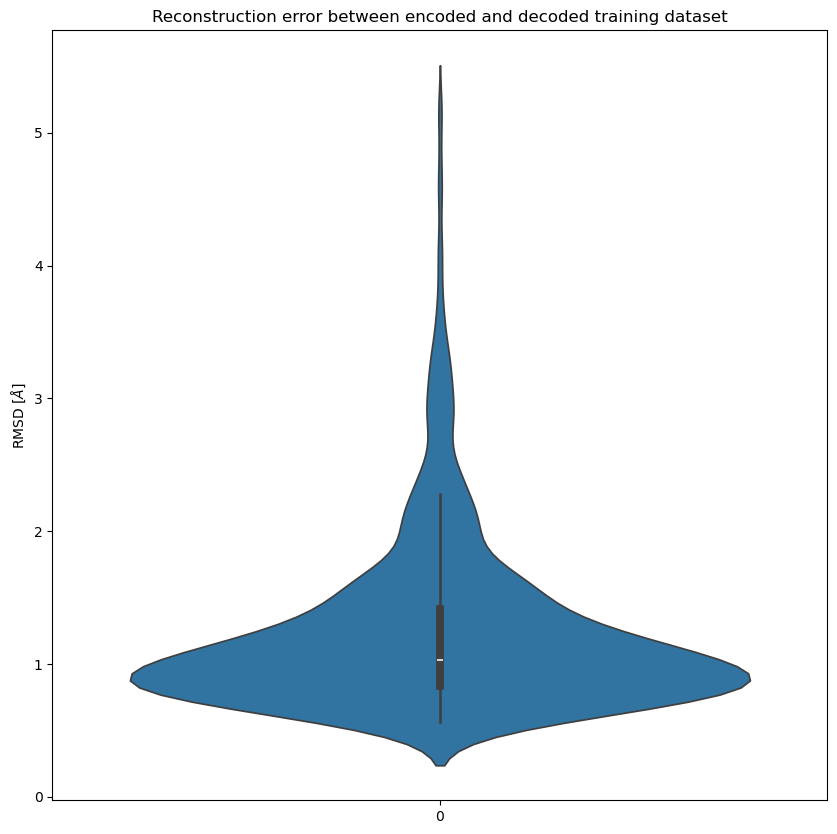

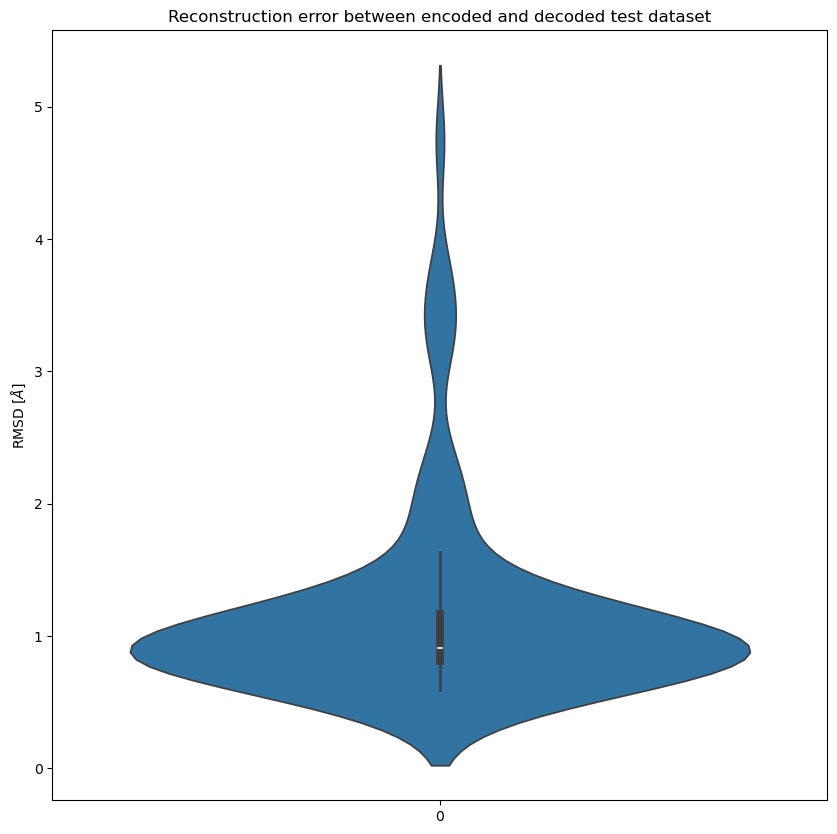

In [21]:

data = [err_train]
f = plt.figure(figsize=(10, 10))
sns.violinplot(data)
plt.ylabel('RMSD [$\AA$]')
plt.title('Reconstruction error between encoded and decoded training dataset')
plt.show()
f.savefig(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.png', dpi=300)

data = [err_test]
f = plt.figure(figsize=(10, 10))
sns.violinplot(data)
plt.ylabel('RMSD [$\AA$]')
plt.title('Reconstruction error between encoded and decoded test dataset')
plt.show()
f.savefig(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.png', dpi=300)

Copied outlier (train): Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/8P71_J.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_train/8P71_J.pdb
Copied outlier (train): Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/8P6V_J.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_train/8P6V_J.pdb
Copied outlier (train): Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/2OH4_A.pdb -> Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_train/2OH4_A.pdb
Copied outlier (train): Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train/7B5O_J.pdb -> Results/run_trial_BRAFActivationLoop_postalign_clea

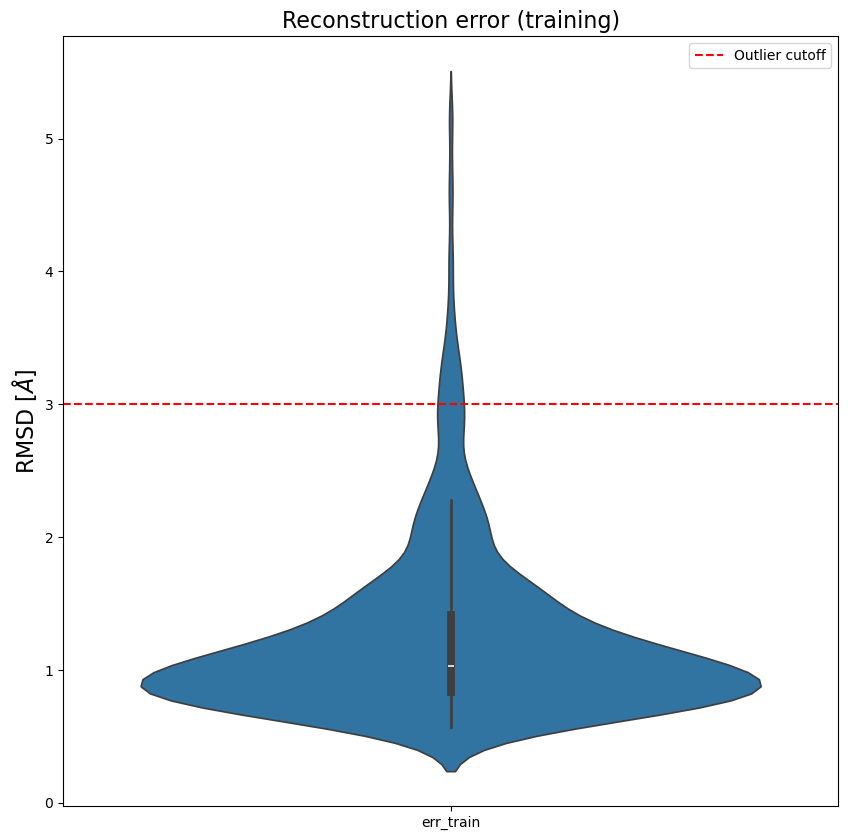

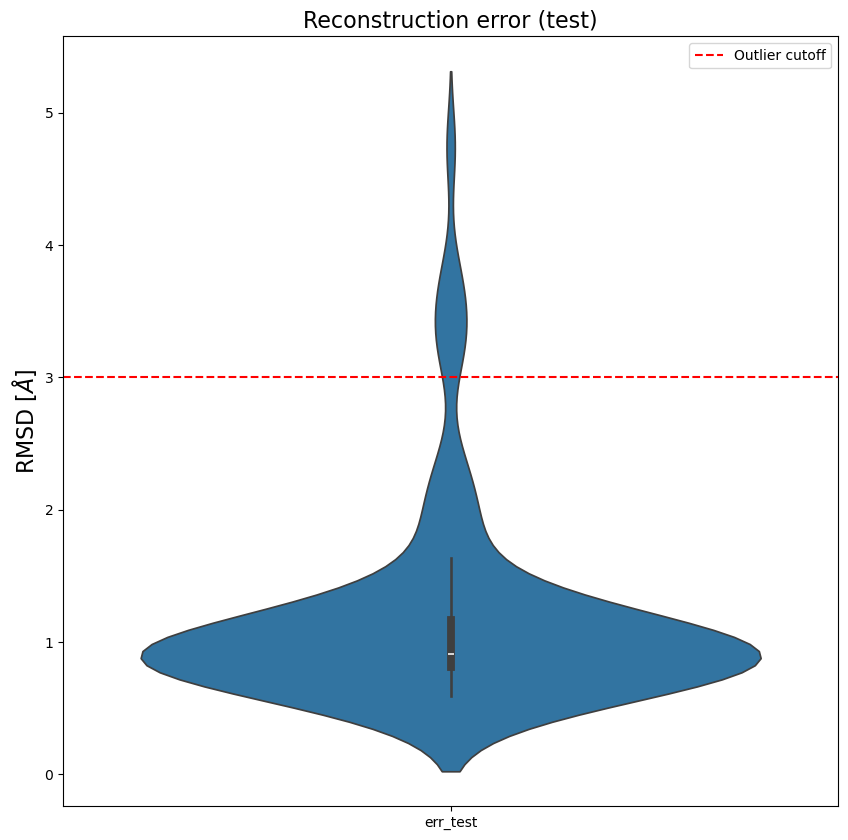

In [26]:
"""
This script filters out PDB structures with reconstruction errors above a 4 Å RMSD threshold, copies them into separate outlier folders for training and test sets, and visualizes the error distributions using violin plots.

"""
saveName = '_foldingnet_checkpoint'
train_err_csv = f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.csv'
test_err_csv = f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.csv'

# Load reconstruction errors from CSV
df_err_train = pd.read_csv(train_err_csv)   
df_err_test = pd.read_csv(test_err_csv)  

#Identify outlier indices with RMSD > 4
train_outlier_indices = df_err_train.index[df_err_train['err_train'] > 4].to_list()
test_outlier_indices = df_err_test.index[df_err_test['err_test'] > 4].to_list()

#Get sorted list of original PDB filenames
folder_name = 'Results/fitted_matlab_segments/mustang_endsAlignment_cleaned_noOutliers'
folder_name = "Results/fitted_matlab_segments/foldseek_endsAlignment_cleaned_noOutliers_noPCAoutliers"


files = sorted([
    f for f in os.listdir(folder_name)
    if os.path.isfile(os.path.join(folder_name, f)) and f != 'combined.pdb'
])

#Create directories to store outlier PDB files
outlier_dir_train = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_train'
outlier_dir_test = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/rmsd_outliers_test'
os.makedirs(outlier_dir_train, exist_ok=True)
os.makedirs(outlier_dir_test, exist_ok=True)

#Copy training outliers into designated folder
source_dir_train = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_train'
for row_i in train_outlier_indices:
    frame_idx = train_indices[row_i]          
    original_filename = files[frame_idx]     

    src = os.path.join(source_dir_train, original_filename)
    dst = os.path.join(outlier_dir_train, original_filename)

    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Copied outlier (train): {src} -> {dst}')
    else:
        print(f'Skipping missing file (train): {src}')

#Copy test outliers into designated folder
source_dir_test = 'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/getDatasetTrial_test'
for row_i in test_outlier_indices:
    frame_idx = test_indices[row_i]
    original_filename = files[frame_idx]

    src = os.path.join(source_dir_test, original_filename)
    dst = os.path.join(outlier_dir_test, original_filename)

    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Copied outlier (test): {src} -> {dst}')
    else:
        print(f'Skipping missing file (test): {src}')

#Plot violin plot for training reconstruction errors
f = plt.figure(figsize=(10, 10))
sns.violinplot(data=[df_err_train['err_train']])
plt.axhline(y=3.0, color='red', linestyle='--', label='Outlier cutoff')
plt.legend()
plt.ylabel('RMSD [$\\AA$]', fontsize=16)
plt.title('Reconstruction error (training)', fontsize=16)
plt.show()
f.savefig(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train_{saveName}.png', dpi=300)

#Plot violin plot for test reconstruction errors
f = plt.figure(figsize=(10, 10))
sns.violinplot(data=[df_err_test['err_test']])
plt.axhline(y=3.0, color='red', linestyle='--', label='Outlier cutoff')
plt.legend()
plt.ylabel('RMSD [$\\AA$]', fontsize=16)
plt.title('Reconstruction error (test)', fontsize=16)
plt.show()
f.savefig(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_test_{saveName}.png', dpi=300)


In [27]:
MA.setup_grid(30)
landscape_err_latent, landscape_err_3d, xaxis, yaxis = MA.scan_error()
df_landscape_err_latent = pd.DataFrame(landscape_err_latent)
df_landscape_err_latent.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_latent_{saveName}.csv', index=False)

df_landscape_err_3d = pd.DataFrame(landscape_err_3d)
df_landscape_err_3d.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_3d_{saveName}.csv', index=False)

df_xaxis = pd.DataFrame(xaxis)
df_xaxis.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_xaxis_{saveName}.csv', index=False)

df_yaxis = pd.DataFrame(yaxis)
df_yaxis.to_csv(f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_yaxis_{saveName}.csv', index=False)

Decoding grid_decoded: 100%|██████████| 113/113 [00:00<00:00, 148.05it/s]


Projection into latent space.

In [28]:
with torch.no_grad():
    z = net.encode(data_train.dataset)

z_training = z.data.cpu().numpy()[:, :, 0]
df_z_train = pd.DataFrame(z_training)

df_z_train['train_index'] = train_indices

mapping_df = pd.read_csv('train_index_mapping_11_newsplit.csv') 
mapping_dict = mapping_df.set_index('train_index')['pdb_filename'].to_dict()

df_z_train['pdb_filename'] = df_z_train['train_index'].map(mapping_dict)

df_z_train.to_csv(
    f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_train_coordinates.csv',
    index=False
)


In [29]:
with torch.no_grad():
    z = net.encode(data_test.dataset)

z_test = z.data.cpu().numpy()[:, :, 0]
df_z_test = pd.DataFrame(z_test)

df_z_test['test_index'] = test_indices

test_mapping_df = pd.read_csv('test_index_mapping_11_newsplit.csv') 
test_mapping_dict = test_mapping_df.set_index('valid_index')['pdb_filename'].to_dict()

df_z_test['pdb_filename'] = df_z_test['test_index'].map(test_mapping_dict)

df_z_test.to_csv(
    f'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_test_coordinates.csv',
    index=False
)

Train: 928 / 938
Test: 102 / 104


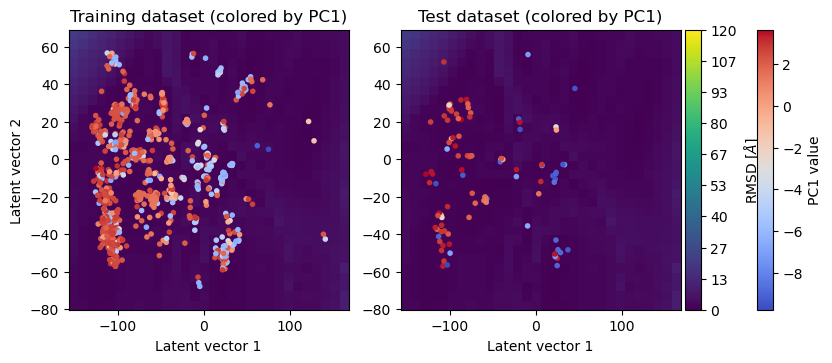

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Load precomputed latent space RMSD landscape (X, Y grid and Z values)
x_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_xaxis__foldingnet_checkpoint.csv")
y_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_yaxis__foldingnet_checkpoint.csv")
z_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_latent__foldingnet_checkpoint.csv")

df_x = [pd.read_csv(file, header=None).to_numpy() for file in x_file]
df_y = [pd.read_csv(file, header=None).to_numpy() for file in y_file]
df_z = [pd.read_csv(file).to_numpy() for file in z_file]

df_z=np.squeeze(np.fliplr(df_z))

# Load PC1 values for each structure
pca_df = pd.read_csv(
    'pc1_ends_noOutliers.txt',
    delim_whitespace=True,
    comment='#',
    header=None,
    names=['PC1_value', 'pdb_filename']
)

pca_df['pdb_filename'] = pca_df['pdb_filename'].str.replace('.pdb', '', regex=False)

# Load latent coordinates and clean filenames
latent_train = pd.read_csv(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_train_coordinates.csv'
)
latent_test = pd.read_csv(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_test_coordinates.csv'
)

latent_train['pdb_filename'] = latent_train['pdb_filename'].str.replace('.pdb', '', regex=False)
latent_test['pdb_filename'] = latent_test['pdb_filename'].str.replace('.pdb', '', regex=False)

# Merge PC1 values into latent coordinate dataframes
merged_train = pd.merge(latent_train, pca_df, on='pdb_filename', how='inner')
merged_test = pd.merge(latent_test, pca_df, on='pdb_filename', how='inner')

print(f"Train: {len(merged_train)} / {len(latent_train)}")
print(f"Test: {len(merged_test)} / {len(latent_test)}")

# Extract coordinates and PC1 values
x_encoded_train = merged_train.iloc[:, 0]
y_encoded_train = merged_train.iloc[:, 1]
pc1_train = merged_train['PC1_value']

x_encoded_test = merged_test.iloc[:, 0]
y_encoded_test = merged_test.iloc[:, 1]
pc1_test = merged_test['PC1_value']

fig = plt.figure(figsize=(8, 8))

# Plot for training data
ax1 = fig.add_axes([0.0, 0.1, 0.35, 0.35])
ax1.imshow(df_z, cmap='viridis', vmin=0., vmax=120.,
           extent=[np.min(df_x), np.max(df_x), np.min(df_y), np.max(df_y)])
ax1.scatter(x_encoded_train, y_encoded_train, c=pc1_train, marker='.', cmap='coolwarm')
ax1.set_xlabel('Latent vector 1')
ax1.set_ylabel('Latent vector 2')
ax1.set_title('Training dataset (colored by PC1)')
ax1.set_aspect('auto')  

# Plot for test data
ax2 = fig.add_axes([0.415, 0.1, 0.35, 0.35])
im = ax2.imshow(df_z, cmap='viridis', vmin=0., vmax=120.,
                extent=[np.min(df_x), np.max(df_x), np.min(df_y), np.max(df_y)])
ax2.scatter(x_encoded_test, y_encoded_test, c=pc1_test, marker='.', cmap='coolwarm')
ax2.set_xlabel('Latent vector 1')
ax2.set_title('Test dataset (colored by PC1)')
ax2.set_aspect('auto')  


# RMSD colorbar
cbar_ax2 = fig.add_axes([0.77, 0.1, 0.02, 0.35])
cbar_ax2.tick_params(left=False, labelleft=False, right=True, labelright=True, labelbottom=False, bottom=False)
cbar = fig.colorbar(im, cax=cbar_ax2, label='RMSD [$\AA$]')
cbar_ticks = np.linspace(0, 120, 10)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([f'{tick:.0f}' for tick in cbar_ticks])

# PC1 colorbar
cbar_ax_pca = fig.add_axes([0.86, 0.1, 0.02, 0.35])
pca_norm = plt.Normalize(vmin=min(pc1_train.min(), pc1_test.min()),
                         vmax=max(pc1_train.max(), pc1_test.max()))
cbar_pca = fig.colorbar(
    plt.cm.ScalarMappable(norm=pca_norm, cmap='coolwarm'),
    cax=cbar_ax_pca,
    label='PC1 value'
)

plt.savefig(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/RMSDlandscapesOnePlot_coloredByPC1.png',
    dpi=300, bbox_inches='tight'
)
plt.show()

Train匹配数量: 928 / 938
Test匹配数量: 102 / 104


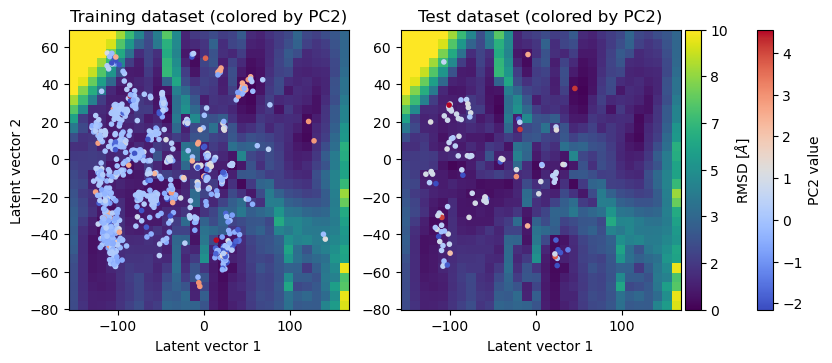

In [31]:
"""
Same as before but using PC2 to color the points 
"""
import pandas as pd
import matplotlib.pyplot as plt
import glob

x_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_xaxis__foldingnet_checkpoint.csv")
y_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_yaxis__foldingnet_checkpoint.csv")
z_file = glob.glob("Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_err_latent__foldingnet_checkpoint.csv")

df_x = [pd.read_csv(file, header=None).to_numpy() for file in x_file]
df_y = [pd.read_csv(file, header=None).to_numpy() for file in y_file]
df_z = [pd.read_csv(file).to_numpy() for file in z_file]

df_z=np.squeeze(np.fliplr(df_z))

pca_df = pd.read_csv(
    'pc2_ends_noOutliers.txt',
    delim_whitespace=True,
    comment='#',
    header=None,
    names=['PC1_value', 'pdb_filename']
)

pca_df['pdb_filename'] = pca_df['pdb_filename'].str.replace('.pdb', '', regex=False)

latent_train = pd.read_csv(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_train_coordinates.csv'
)
latent_test = pd.read_csv(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/landscape_encoded_test_coordinates.csv'
)

latent_train['pdb_filename'] = latent_train['pdb_filename'].str.replace('.pdb', '', regex=False)
latent_test['pdb_filename'] = latent_test['pdb_filename'].str.replace('.pdb', '', regex=False)

merged_train = pd.merge(latent_train, pca_df, on='pdb_filename', how='inner')
merged_test = pd.merge(latent_test, pca_df, on='pdb_filename', how='inner')

print(f"Train匹配数量: {len(merged_train)} / {len(latent_train)}")
print(f"Test匹配数量: {len(merged_test)} / {len(latent_test)}")

x_encoded_train = merged_train.iloc[:, 0]
y_encoded_train = merged_train.iloc[:, 1]
pc1_train = merged_train['PC1_value']

x_encoded_test = merged_test.iloc[:, 0]
y_encoded_test = merged_test.iloc[:, 1]
pc1_test = merged_test['PC1_value']

fig = plt.figure(figsize=(8, 8))

ax1 = fig.add_axes([0.0, 0.1, 0.35, 0.35])
ax1.imshow(df_z, cmap='viridis', vmin=0., vmax=10.,
           extent=[np.min(df_x), np.max(df_x), np.min(df_y), np.max(df_y)])
ax1.scatter(x_encoded_train, y_encoded_train, c=pc1_train, marker='.', cmap='coolwarm')
ax1.set_xlabel('Latent vector 1')
ax1.set_ylabel('Latent vector 2')
ax1.set_title('Training dataset (colored by PC2)')
ax1.set_aspect('auto')  

ax2 = fig.add_axes([0.415, 0.1, 0.35, 0.35])
im = ax2.imshow(df_z, cmap='viridis', vmin=0., vmax=10.,
                extent=[np.min(df_x), np.max(df_x), np.min(df_y), np.max(df_y)])
ax2.scatter(x_encoded_test, y_encoded_test, c=pc1_test, marker='.', cmap='coolwarm')
ax2.set_xlabel('Latent vector 1')
ax2.set_title('Test dataset (colored by PC2)')
ax2.set_aspect('auto')  

cbar_ax2 = fig.add_axes([0.77, 0.1, 0.02, 0.35])
cbar_ax2.tick_params(left=False, labelleft=False, right=True, labelright=True, labelbottom=False, bottom=False)
cbar = fig.colorbar(im, cax=cbar_ax2, label='RMSD [$\AA$]')
cbar_ticks = np.linspace(0, 10, 7)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([f'{tick:.0f}' for tick in cbar_ticks])

cbar_ax_pca = fig.add_axes([0.86, 0.1, 0.02, 0.35])
pca_norm = plt.Normalize(vmin=min(pc1_train.min(), pc1_test.min()),
                         vmax=max(pc1_train.max(), pc1_test.max()))
cbar_pca = fig.colorbar(
    plt.cm.ScalarMappable(norm=pca_norm, cmap='coolwarm'),
    cax=cbar_ax_pca,
    label='PC2 value'
)

plt.savefig(
    'Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/RMSDlandscapesOnePlot_coloredByPC2.png',
    dpi=300, bbox_inches='tight'
)
plt.show()

In [4]:
import pandas as pd
error_df=pd.read_csv("/data/student/xujia/autoencoder_new/Results/run_trial_BRAFActivationLoop_postalign_cleaned_noOutlier_11_checkpoint_newsplit/err_train__foldingnet_checkpoint.csv")

In [7]:
error_df[error_df["err_train"]>15].to_csv("RMSD>15.csv",index=True)